In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/US_Accidents_March23.csv")

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [5]:
df["Weather_Condition"].value_counts()

Weather_Condition
Fair                         2560802
Mostly Cloudy                1016195
Cloudy                        817082
Clear                         808743
Partly Cloudy                 698972
                              ...   
Heavy Sleet / Windy                1
Sand / Windy                       1
Heavy Rain Shower / Windy          1
Blowing Snow Nearby                1
Drifting Snow                      1
Name: count, Length: 144, dtype: int64

In [6]:
mi_rows = df[df["State"] == "MI"].shape[0]
print(mi_rows)

162191


In [7]:
mi_accidents = df.loc[df["State"] == "MI"].copy()

city_counts = (
    mi_accidents["City"]
    .value_counts()
    .rename_axis("City")
    .reset_index(name="AccidentCount")
)


print(city_counts.head(30))

                  City  AccidentCount
0              Detroit          24452
1         Grand Rapids          24379
2                Flint          20651
3          Grand Blanc           4113
4           Southfield           3135
5               Burton           2797
6              Davison           2605
7        Highland Park           2334
8                 Clio           2192
9            Ann Arbor           2008
10           Royal Oak           1950
11            Plymouth           1928
12     Madison Heights           1855
13          Farmington           1818
14              Warren           1782
15             Lansing           1756
16  Saint Clair Shores           1747
17                Novi           1688
18        Mount Morris           1668
19             Romulus           1621
20              Fenton           1458
21           Roseville           1441
22        Swartz Creek           1429
23            Dearborn           1378
24             Livonia           1299
25          

In [8]:
city_counts["Percent"] = (
    city_counts["AccidentCount"]
    / city_counts["AccidentCount"].sum()
    * 100
)

city_counts["CumulativePercent"] = city_counts["Percent"].cumsum()

print(city_counts.head(30))

                  City  AccidentCount    Percent  CumulativePercent
0              Detroit          24452  15.076238          15.076238
1         Grand Rapids          24379  15.031229          30.107467
2                Flint          20651  12.732676          42.840143
3          Grand Blanc           4113   2.535930          45.376074
4           Southfield           3135   1.932930          47.309004
5               Burton           2797   1.724531          49.033535
6              Davison           2605   1.606151          50.639686
7        Highland Park           2334   1.439062          52.078748
8                 Clio           2192   1.351510          53.430257
9            Ann Arbor           2008   1.238062          54.668319
10           Royal Oak           1950   1.202301          55.870620
11            Plymouth           1928   1.188737          57.059357
12     Madison Heights           1855   1.143727          58.203084
13          Farmington           1818   1.120914

In [14]:
city_locations = (
    mi_accidents
    .dropna(subset=["City", "Start_Lat", "Start_Lng"])
    .groupby("City")
    .agg(
        AccidentCount=("City", "size"),
        Latitude = ("Start_Lat", "median"),
        Longitude = ("Start_Lng", "median")
    )
    .reset_index()
    .sort_values("AccidentCount", ascending=False)
)

print(city_locations.head(30))

                   City  AccidentCount   Latitude  Longitude
137             Detroit          24452  42.378016 -83.099335
217        Grand Rapids          24379  42.957733 -85.664978
180               Flint          20651  43.010441 -83.707565
213         Grand Blanc           4113  42.920155 -83.639183
511          Southfield           3135  42.487476 -83.263184
74               Burton           2797  43.003906 -83.634529
131             Davison           2605  43.019430 -83.518051
252       Highland Park           2334  42.418090 -83.088470
112                Clio           2192  43.177437 -83.756310
16            Ann Arbor           2008  42.298166 -83.738579
473           Royal Oak           1950  42.476501 -83.116127
436            Plymouth           1928  42.383390 -83.437057
330     Madison Heights           1855  42.504543 -83.114975
171          Farmington           1818  42.494996 -83.365213
559              Warren           1782  42.490872 -83.045380
307             Lansing 

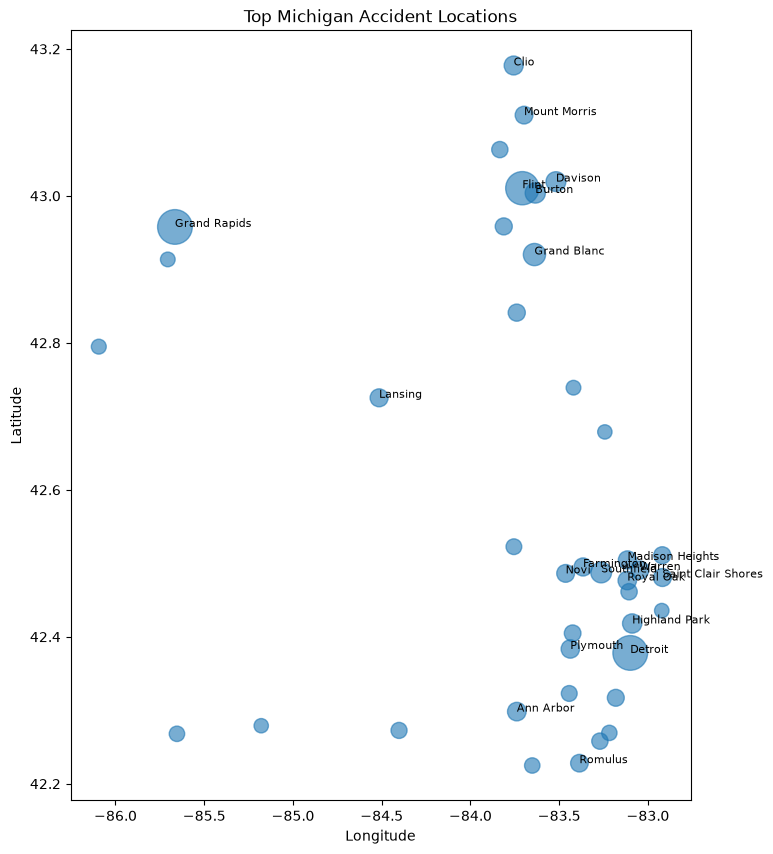

In [19]:
import matplotlib.pyplot as plt


top_cities = city_locations.head(40)

plt.figure(figsize=(8, 10))

plt.scatter(
    top_cities["Longitude"],
    top_cities["Latitude"],
    s=top_cities["AccidentCount"] ** 0.5 * 4,
    alpha=0.6,
)

for _, row in top_cities.head(20).iterrows():
    plt.text(
        row["Longitude"],
        row["Latitude"],
        row["City"],
        fontsize=8,
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top Michigan Accident Locations")

plt.show()